In [1]:
from juliacall import Main as jl 
import petthermotools as ptt 
import numpy as np

# import os
# os.environ["JULIA_NUM_THREADS"] = str(ptt.memory_limit(cores = ptt.core_config.MAX_WORKERS))
ptt.activate_petthermotools_env()

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
alphaMELTS for Python files successfully located.
Julia environment detected.


  Activating project at `~/.petthermotools_julia_env`
Precompiling MAGEMinCalc...
    622.8 ms  ? PythonCall
Info Given MAGEMinCalc was explicitly requested, output will be shown live 
Using libMAGEMin.dylib from MAGEMin_jll
┌ Warning: Module PythonCall with build ID fafbfcfd-3501-17ed-0393-e686105ae5fb is missing from the cache.
│ This may mean PythonCall [6099a3de-0909-46bc-b1f4-468b9a2dfc0d] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2541
   1325.1 ms  ? MAGEMinCalc
[ Info: Precompiling MAGEMinCalc [dd69d18c-a947-4316-a873-d8ea006ff1b2] (cache misses: wrong dep version loaded (2), mismatched flags (2))
┌ Warning: Module PythonCall with build ID fafbfcfd-3501-17ed-0393-e686105ae5fb is missing from the cache.
│ This may mean PythonCall [6099a3de-0909-46bc-b1f4-468b9a2dfc0d] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2541
┌ Info: Skipping precompilation due to precompilable error. Importing 

Using libMAGEMin.dylib from MAGEMin_jll
Using libMAGEMin.dylib from MAGEMin_jll
      From worker 5:	Using libMAGEMin.dylib from MAGEMin_jll
      From worker 4:	Using libMAGEMin.dylib from MAGEMin_jll
      From worker 3:	Using libMAGEMin.dylib from MAGEMin_jll
      From worker 2:	Using libMAGEMin.dylib from MAGEMin_jll


In [2]:
ptt.test_MAGEMinCalc()

  Activating project at `~/.petthermotools_julia_env`


        SiO2     Al2O3       CaO       MgO       FeO       K2O      Na2O  \
0   0.476274  0.164389  0.116268  0.094076  0.091816  0.003301  0.022563   
1   0.476392  0.164591  0.116417  0.093560  0.091808  0.003302  0.022594   
2   0.476478  0.164839  0.116578  0.093042  0.091749  0.003308  0.022631   
3   0.476612  0.165051  0.116723  0.092529  0.091674  0.003310  0.022670   
4   0.476739  0.165279  0.116860  0.092015  0.091639  0.003313  0.022695   
5   0.476878  0.165454  0.117010  0.091500  0.091594  0.003318  0.022725   
6   0.476966  0.165689  0.117151  0.090995  0.091557  0.003319  0.022757   
7   0.477047  0.165926  0.117307  0.090485  0.091533  0.003321  0.022781   
8   0.477152  0.166162  0.117473  0.089985  0.091480  0.003327  0.022791   
9   0.477226  0.166412  0.117624  0.089484  0.091427  0.003329  0.022818   
10  0.477266  0.166651  0.117765  0.088976  0.091434  0.003336  0.022843   
11  0.477415  0.166868  0.117910  0.088480  0.091346  0.003345  0.022876   
12  0.477487

In [2]:
starting_comp = {"SiO2": 47.5,
"TiO2":          2.29,
"Al2O3":         16.4,
"FeOt":          9.16,
"MnO":          0.123,
"MgO":           9.38,
"CaO":           11.6,
"Na2O":          2.25,
"K2O":          0.329,
"P2O5":         0.257,
"H2O":           0.68,
"CO2":          0.028,
"Cr2O3":         0.05}

In [8]:
Results = ptt.phaseDiagram_calc(Model="Green2025",
                                bulk=starting_comp,
                                T_C = np.linspace(800,1400,25),
                                P_bar = np.linspace(250,10000,25),
                                Fe3Fet_init=0.15, refine = 2)

Computing 156 points... 100%|████████████████████████████| Time: 0:00:22
Computing 156 points... 100%|████████████████████████████| Time: 0:00:22
Computing 156 points... 100%|████████████████████████████| Time: 0:00:22
Computing 157 points... 100%|████████████████████████████| Time: 0:00:23
Performing another 544 calculations with interpolation used to calculate 1232 points.
Computing 136 points... 100%|████████████████████████████| Time: 0:00:13
Computing 136 points... 100%|████████████████████████████| Time: 0:00:14
Computing 136 points... 100%|████████████████████████████| Time: 0:00:15
Computing 136 points... 100%|████████████████████████████| Time: 0:00:15
Performing another 1268 calculations with interpolation used to calculate 5740 points.
Computing 317 points... 100%|████████████████████████████| Time: 0:00:30
Computing 317 points... 100%|████████████████████████████| Time: 0:00:34
Computing 317 points... 100%|████████████████████████████| Time: 0:00:35
Computing 317 points... 

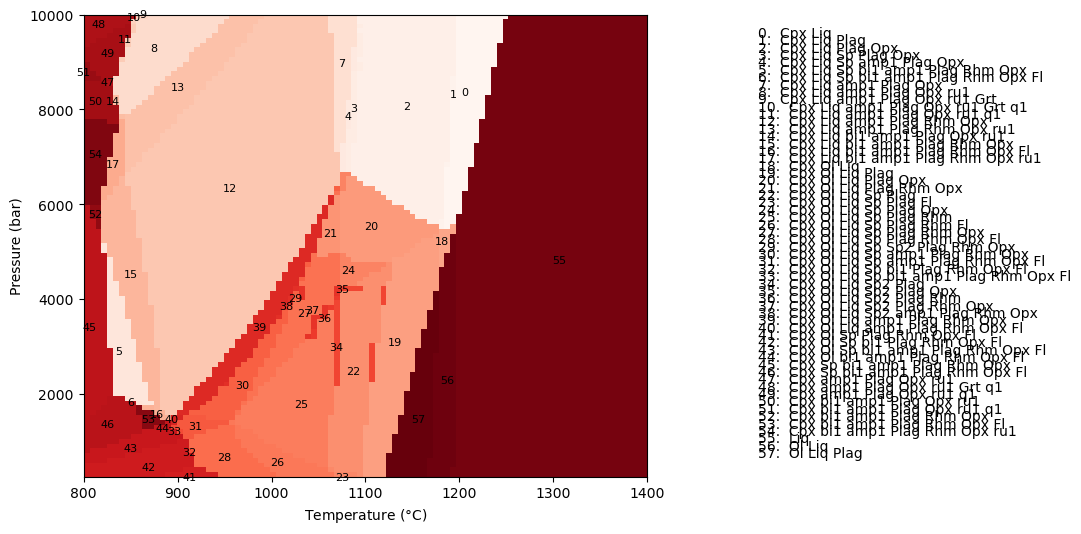

(<Figure size 1000x600 with 2 Axes>,
 array([<Axes: xlabel='Temperature ($\\degree$C)', ylabel='Pressure (bar)'>,
        <Axes: >], dtype=object))

In [9]:
ptt.plot_phaseDiagram(Combined=Results)

In [3]:
Results = ptt.isothermal_decompression(Model = "Green2025",
                             bulk=starting_comp,
                             P_start_bar = 2000,
                             P_end_bar = 50,
                             dp_bar = 10,
                             find_liquidus=True,
                             Frac_solid=False,
                             fO2_buffer="FMQ",
                             fO2_offset=[-1.0,0.0,1.0,2.0],
                             label = "fO2")

A default timeout of 5 minutes has been specified. If you are not getting any results try increasing this using the timeout kwarg.
None
[None, None, None, None]
Any[nothing, nothing, nothing, nothing]
Computing 196 points... 100%|████████████████████████████| Time: 0:00:35
Computing 196 points... 100%|████████████████████████████| Time: 0:00:36
Computing 196 points... 100%|████████████████████████████| Time: 0:00:36
Computing 196 points... 100%|████████████████████████████| Time: 0:00:36


(<Figure size 960x900 with 9 Axes>,
 array([[<Axes: xlabel='MgO', ylabel='SiO$_2$'>,
         <Axes: xlabel='MgO', ylabel='TiO$_2$'>,
         <Axes: xlabel='MgO', ylabel='Al$_2$O$_3$'>],
        [<Axes: xlabel='MgO', ylabel='Cr$_2$O$_3$'>,
         <Axes: xlabel='MgO', ylabel='FeO$_t$'>,
         <Axes: xlabel='MgO', ylabel='CaO'>],
        [<Axes: xlabel='MgO', ylabel='Na$_2$O'>,
         <Axes: xlabel='MgO', ylabel='K$_2$O'>, <Axes: >]], dtype=object))

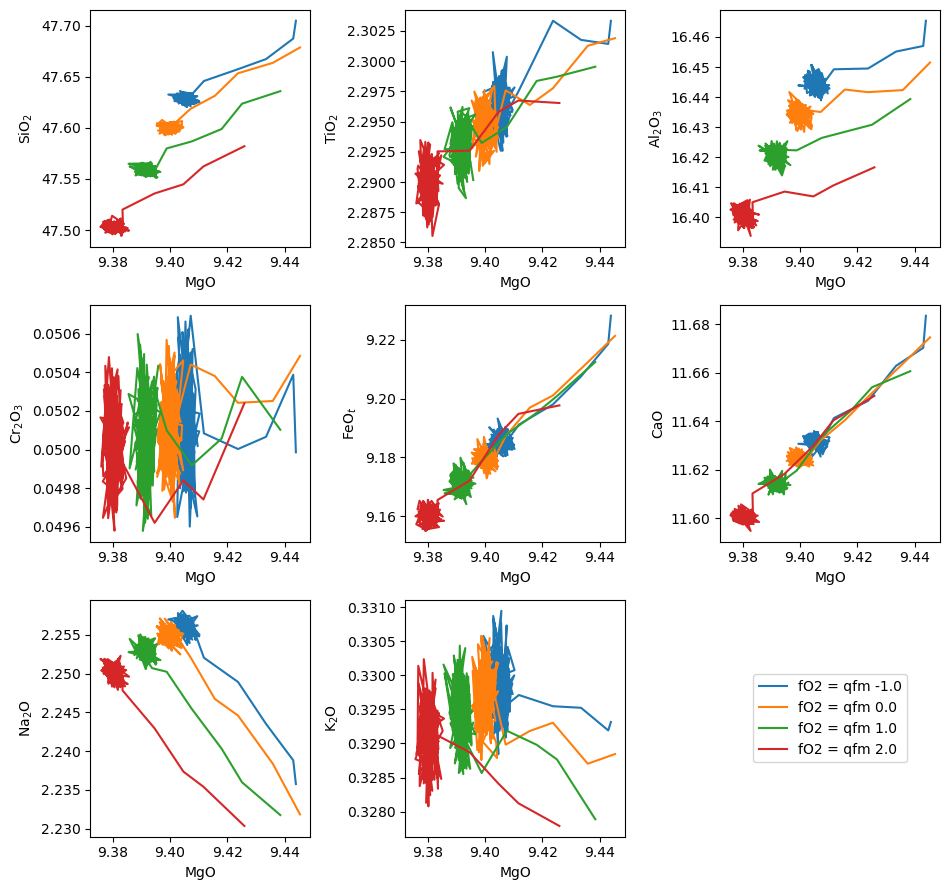

In [4]:
ptt.harker(Results=Results)

In [2]:
ptt.activate_petthermotools_env()

  Activating project at `~/.petthermotools_julia_env`


In [3]:
jl.seval(""" 
         using Pkg
         Pkg.rm("MAGEMin_C")
         """)

    Updating `~/.petthermotools_julia_env/Project.toml`
  [e5d170eb] - MAGEMin_C v2.1.5
  No Changes to `~/.petthermotools_julia_env/Manifest.toml`


In [4]:
jl.seval("""using Pkg; Pkg.add(name="MAGEMin_C", version = "2.1.5")""")

   Resolving package versions...
    Updating `~/.petthermotools_julia_env/Project.toml`
  [e5d170eb] ↑ MAGEMin_C v2.1.0 ⇒ v2.1.5
    Updating `~/.petthermotools_julia_env/Manifest.toml`
  [e5d170eb] ↑ MAGEMin_C v2.1.0 ⇒ v2.1.5
  [763ebaa8] ↑ MAGEMin_jll v1.8.7+0 ⇒ v1.8.9+0
Precompiling project...
   1988.2 ms  ✓ MAGEMinCalc
  1 dependency successfully precompiled in 3 seconds. 115 already precompiled.
  1 dependency precompiled but a different version is currently loaded. Restart julia to access the new version. Otherwise, loading dependents of this package may trigger further precompilation to work with the unexpected version.
  1 dependency had output during precompilation:
┌ MAGEMinCalc
│  Using libMAGEMin.dylib from MAGEMin_jll
└  
